### Report Plot

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
C:\Users\chris\AppData\Local\Temp\ipykernel_13408\998193621.py:59: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.25)


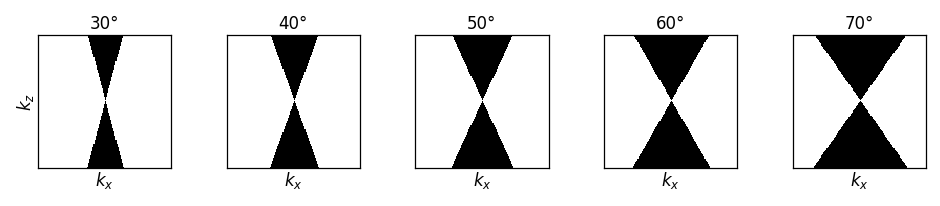

In [1]:
import torch
import matplotlib.pyplot as plt
from ddw.utils.missing_wedge import get_missing_wedge_mask
from pathlib import Path

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

angles = [30, 40, 50, 60, 70]
grid_size = (128, 128, 128)

cm = 1 / 2.54
fig, axes = plt.subplots(
    1, len(angles),
    figsize=(16 * cm, 3.2 * cm),
    constrained_layout=True
)


for i, (ax, angle) in enumerate(zip(axes, angles)):
    mask = get_missing_wedge_mask(grid_size, mw_angle=angle)
    mid_y = mask.shape[1] // 2
    sl = mask[:, mid_y, :].numpy()

    ax.imshow(
        sl,
        cmap="gray",
        origin="lower",
        vmin=0,
        vmax=1,
        extent=[-1, 1, -1, 1],
        interpolation="nearest"
    )

    ax.set_title(f"{angle}°", pad=3)
    ax.set_aspect("equal")

    ax.set_xlabel(r"$k_x$", labelpad=1)

    if i == 0:
        ax.set_ylabel(r"$k_z$", labelpad=1)
    else:
        ax.set_ylabel("")

    # clean schematic axes: no numerical tick labels
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

fig.subplots_adjust(wspace=0.25)

### Adjust Figure for report

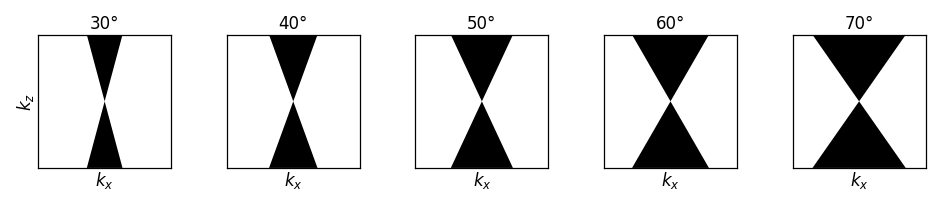

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

angles = [30, 40, 50, 60, 70]

cm = 1 / 2.54
fig, axes = plt.subplots(
    1, len(angles),
    figsize=(16 * cm, 3.2 * cm),
    constrained_layout=True
)

for i, (ax, angle) in enumerate(zip(axes, angles)):
    ax.set_facecolor("white")

    # Width of wedge at top/bottom boundary.
    # This gives a clean schematic similar to your current plot.
    half_width = np.tan(np.deg2rad(angle / 2))
    half_width = min(half_width, 1.0)

    top_wedge = Polygon(
        [(-half_width, 1), (half_width, 1), (0, 0)],
        closed=True,
        facecolor="black",
        edgecolor="black",
        linewidth=0
    )

    bottom_wedge = Polygon(
        [(-half_width, -1), (half_width, -1), (0, 0)],
        closed=True,
        facecolor="black",
        edgecolor="black",
        linewidth=0
    )

    ax.add_patch(top_wedge)
    ax.add_patch(bottom_wedge)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")

    ax.set_title(f"{angle}°", pad=3)
    ax.set_xlabel(r"$k_x$", labelpad=1)

    if i == 0:
        ax.set_ylabel(r"$k_z$", labelpad=1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

plt.show()

In [3]:
export_dir = Path("../../figures/final_report")

save_png = export_dir / f"Missing_Wedge_Visual.png"
save_pdf = export_dir / f"Missing_Wedge_Visual.pdf"

fig.savefig(
    save_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

fig.savefig(
    save_pdf,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

print("Saved:", save_png)
print("Saved:", save_pdf)

Saved: ..\..\figures\final_report\Missing_Wedge_Visual.png
Saved: ..\..\figures\final_report\Missing_Wedge_Visual.pdf


In [3]:
angle = 50
mask = get_missing_wedge_mask((128, 128, 128), mw_angle=angle)

fraction_ones = mask.float().mean().item()
fraction_zeros = 1 - fraction_ones

print(f"mw_angle = {angle}°")
print(f"Fraction mask == 1: {fraction_ones:.4f}")
print(f"Fraction mask == 0: {fraction_zeros:.4f}")

mw_angle = 50°
Fraction mask == 1: 0.7673
Fraction mask == 0: 0.2327


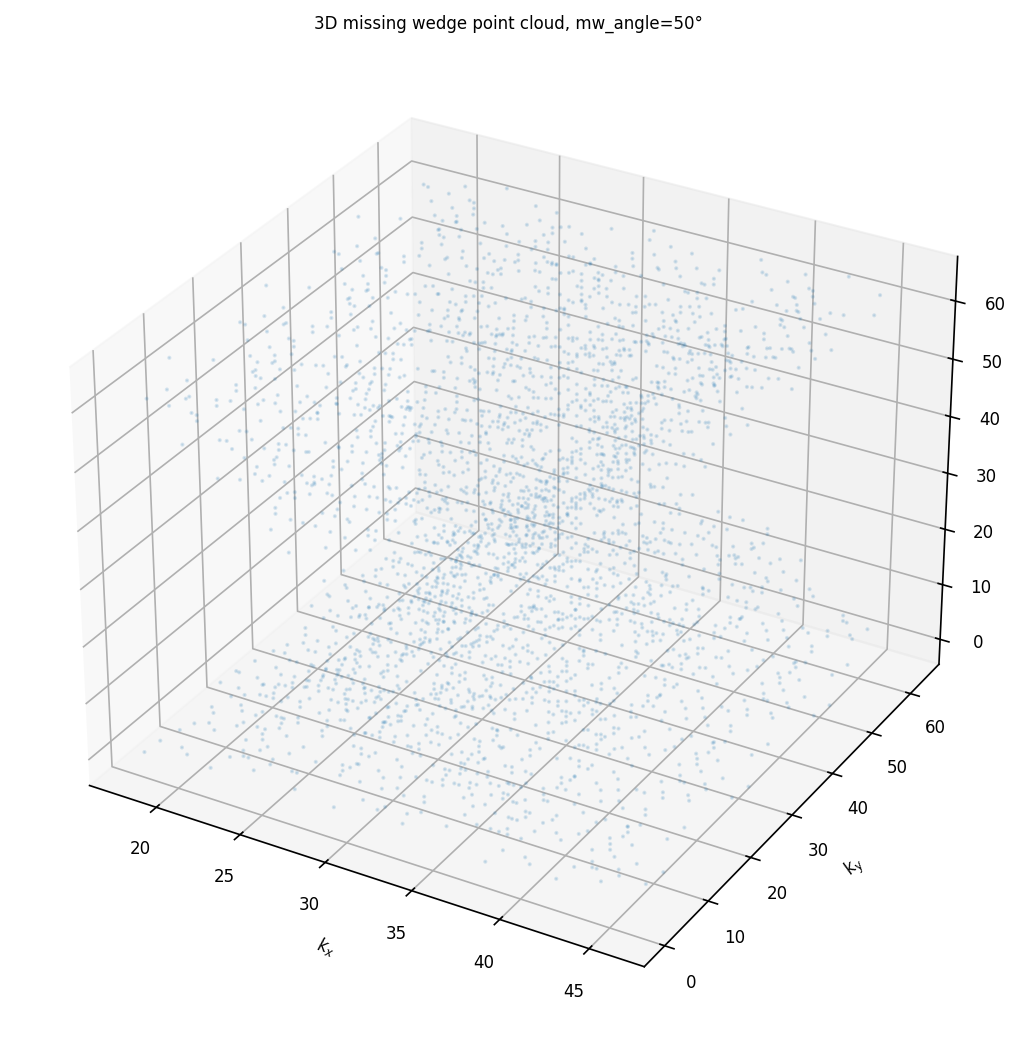

In [4]:
import torch
import matplotlib.pyplot as plt
from ddw.utils.missing_wedge import get_missing_wedge_mask

angle = 50
grid_size = (64, 64, 64)

mask = get_missing_wedge_mask(grid_size, mw_angle=angle)

# Tensor order is [z, y, x].
# We plot the zero-region as the missing wedge if mask is a keep-mask.
# If this looks inverted, switch missing = mask.
missing = 1 - mask

z, y, x = torch.where(missing > 0)

# Downsample points so plotting stays fast
step = 20
z = z[::step]
y = y[::step]
x = x[::step]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x.numpy(), y.numpy(), z.numpy(), s=1, alpha=0.15)

ax.set_title(f"3D missing wedge point cloud, mw_angle={angle}°")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("$k_z$")

plt.tight_layout()
plt.show()

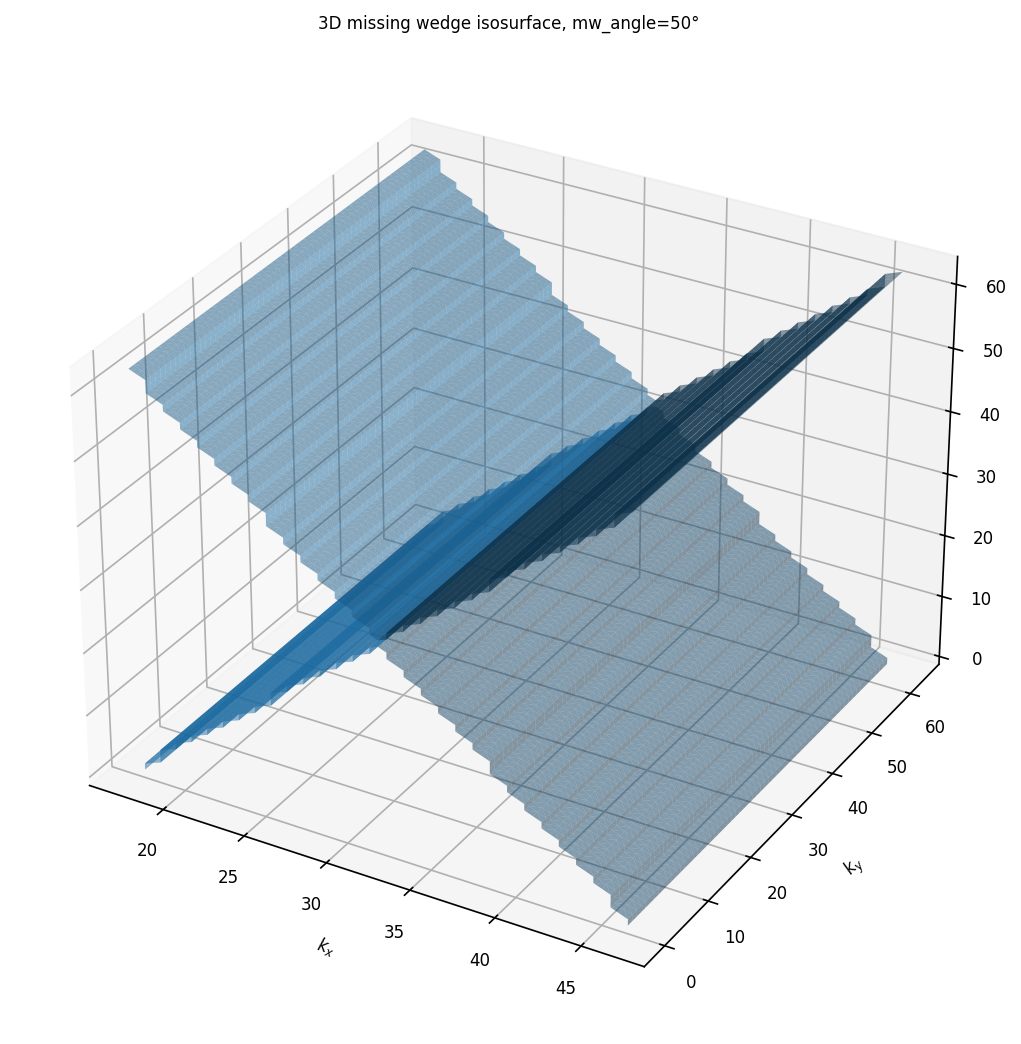

In [5]:
import torch
import matplotlib.pyplot as plt
from skimage import measure
from ddw.utils.missing_wedge import get_missing_wedge_mask

angle = 50
grid_size = (64, 64, 64)

mask = get_missing_wedge_mask(grid_size, mw_angle=angle)
missing = (1 - mask).numpy().astype(float)

verts, faces, normals, values = measure.marching_cubes(missing, level=0.5)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(
    verts[:, 2],  # x
    verts[:, 1],  # y
    faces,
    verts[:, 0],  # z
    linewidth=0.1,
    alpha=0.5
)

ax.set_title(f"3D missing wedge isosurface, mw_angle={angle}°")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("$k_z$")

plt.tight_layout()
plt.show()

In [6]:
#fig.savefig("missing_wedge_masks_3d_isosurface.png", dpi=200, bbox_inches="tight")